In [1]:
!pip install yfinance ta


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=9e0e1b01d58b7f54550423f22578572ba131c612a609d9c2612fc48ec8f2de98
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import SMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Download data
df = yf.download('RELIANCE.NS', start='2019-01-01', end='2024-12-31')
df.dropna(inplace=True)

print(df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

(1480, 5)
Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2019-01-01  496.196350  498.985004  491.371623  498.077593     9746670
2019-01-02  489.733917  498.852251  487.343655  493.319266    15628818
2019-01-03  483.691895  493.363509  482.518910  490.220786    16288287
2019-01-04  486.303467  488.870779  478.535197  485.750186    18516544
2019-01-07  489.003540  495.067675  487.343638  489.999475    12060290


Price        Close         High          Low         Open        Volume
count  1480.000000  1480.000000  1480.000000  1480.000000  1.480000e+03
mean   1011.537643  1022.591700  1001.454606  1012.364129  1.955111e+07
std     283.545445   284.994175   282.119813   283.547313  1.522803e+07
min     393.662354   423.029501   389.921870   407.978540  1.705656e+06
25%     823.274826   836.002710   808.617400   821.576697  1.063978e+07
50%    1075.770264  1087.571156  1065.794340  1076.053705  1.501979e+07
75%    1191.074219  1204.188658  1182.400716  1193.019831  2.216523e+07
max    1581.824463  1589.630354  1566.607971  1585.332124  1.426834e+08


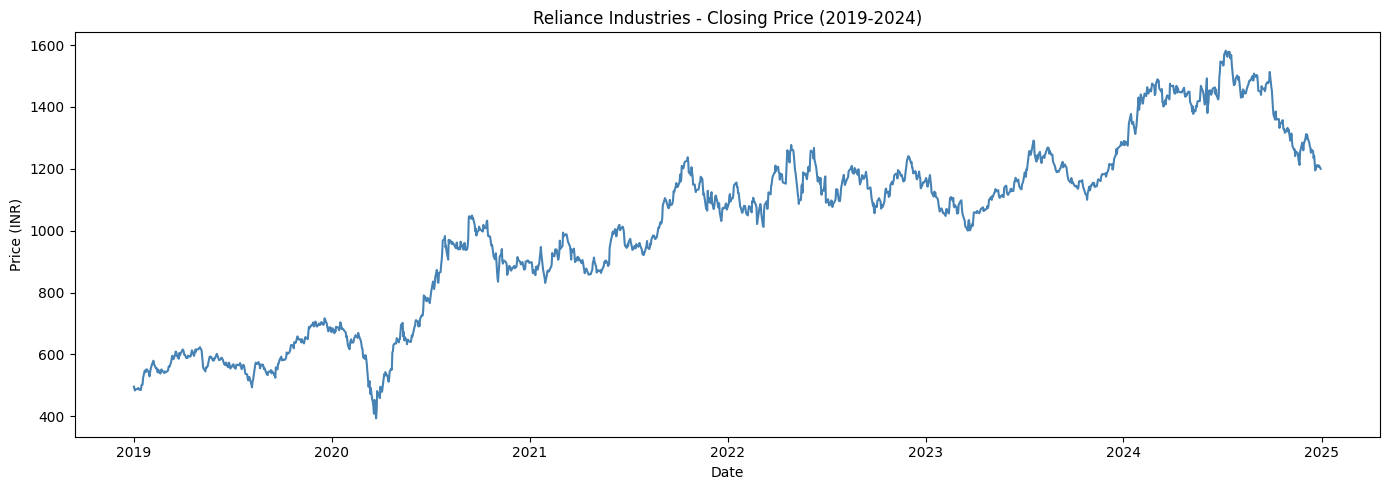

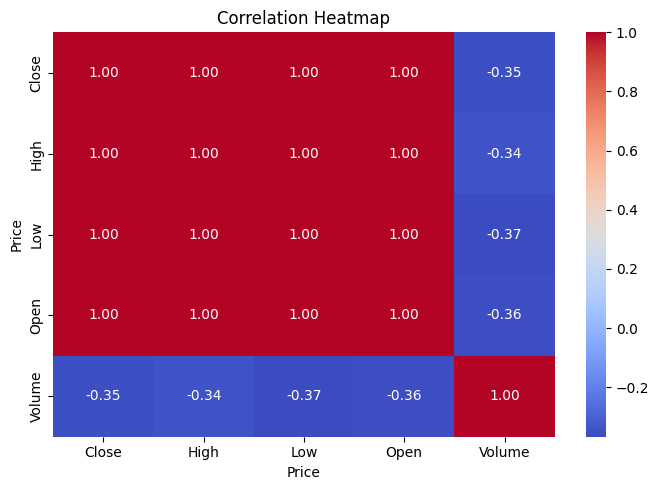

In [3]:
# Flatten multi-level columns
df.columns = df.columns.get_level_values(0)

# Basic statistics
print(df.describe())

# Plot closing price over time
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='steelblue')
plt.title('Reliance Industries - Closing Price (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.savefig('closing_price.png', dpi=150)
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [4]:
# Technical indicators
df['SMA_7'] = SMAIndicator(close=df['Close'], window=7).sma_indicator()
df['SMA_21'] = SMAIndicator(close=df['Close'], window=21).sma_indicator()
df['RSI'] = RSIIndicator(close=df['Close'], window=14).rsi()

macd = MACD(close=df['Close'])
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

bb = BollingerBands(close=df['Close'])
df['BB_High'] = bb.bollinger_hband()
df['BB_Low'] = bb.bollinger_lband()

# Lagged features
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df['Close_lag5'] = df['Close'].shift(5)

# Drop rows with NaN from indicator calculations
df.dropna(inplace=True)

print(df.shape)
print(df[['Close', 'SMA_7', 'SMA_21', 'RSI', 'MACD']].head())

(1447, 15)
Price            Close       SMA_7      SMA_21        RSI      MACD
Date                                                               
2019-02-18  540.061890  554.339975  551.170893  49.788692  9.981813
2019-02-19  538.291199  549.641697  551.840117  48.905995  8.212309
2019-02-20  546.369385  546.900513  551.769508  52.999882  7.376772
2019-02-21  551.924438  546.498971  552.017177  55.632512  7.081221
2019-02-22  545.484131  544.978210  552.144703  51.996166  6.255209


In [5]:
# Define features and target
features = ['Open', 'High', 'Low', 'Volume', 'SMA_7', 'SMA_21',
            'RSI', 'MACD', 'MACD_Signal', 'BB_High', 'BB_Low',
            'Close_lag1', 'Close_lag2', 'Close_lag5']

target = 'Close'

X = df[features].values
y = df[target].values

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Train/test split — 80/20, no shuffling (time series order matters)
split = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1157
Testing samples: 290


Linear Regression → RMSE: 18.03 | R²: 0.9756
Random Forest     → RMSE: 20.46 | R²: 0.9686


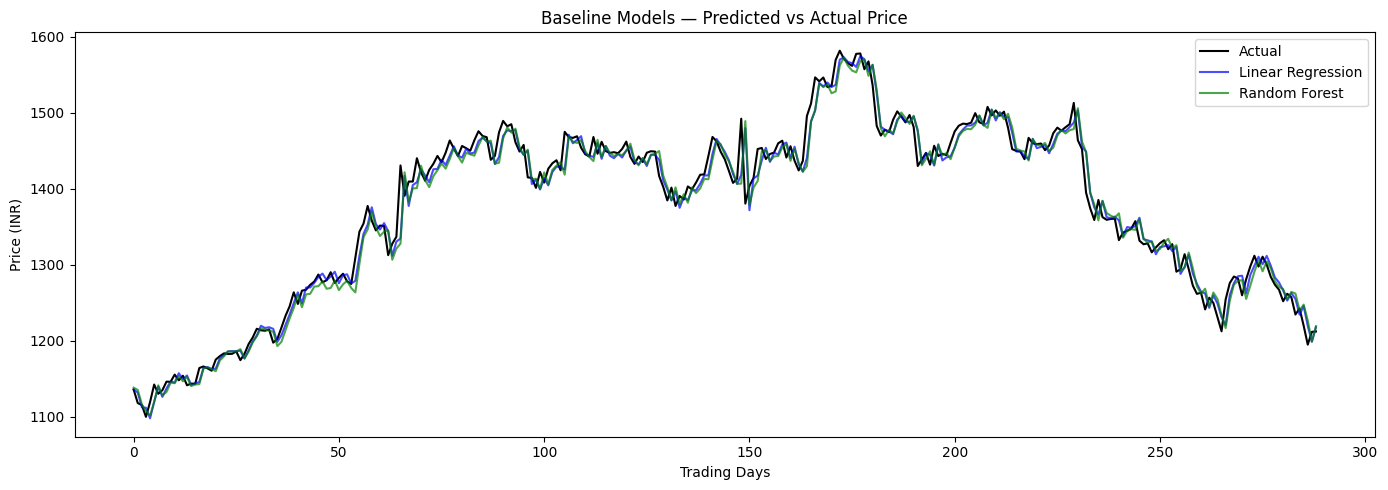

In [12]:
# Use daily returns instead of raw prices
df['Return'] = df['Close'].pct_change()
df['Target_Return'] = df['Return'].shift(-1)  # predict next day's return
df.dropna(inplace=True)

features_r = ['SMA_7', 'SMA_21', 'RSI', 'MACD',
              'MACD_Signal', 'BB_High', 'BB_Low',
              'Close_lag1', 'Close_lag2', 'Close_lag5', 'Return']

X_r = df[features_r].values
y_price = df['Close'].values

scaler_X3 = MinMaxScaler()
X_r_scaled = scaler_X3.fit_transform(X_r)

split = int(len(X_r_scaled) * 0.8)
X_train3, X_test3 = X_r_scaled[:split], X_r_scaled[split:]
y_train3 = df['Target_Return'].values[:split]

# actual prices for test period
actual_prices = y_price[split:]
prev_prices = y_price[split-1:-1]

# Linear Regression on returns
lr2 = LinearRegression()
lr2.fit(X_train3, y_train3)
lr_ret_pred = lr2.predict(X_test3)
lr_price_pred = prev_prices * (1 + lr_ret_pred)

# Random Forest on returns
rf2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf2.fit(X_train3, y_train3)
rf_ret_pred = rf2.predict(X_test3)
rf_price_pred = prev_prices * (1 + rf_ret_pred)

lr_rmse = np.sqrt(mean_squared_error(actual_prices, lr_price_pred))
lr_r2 = r2_score(actual_prices, lr_price_pred)
rf_rmse = np.sqrt(mean_squared_error(actual_prices, rf_price_pred))
rf_r2 = r2_score(actual_prices, rf_price_pred)

print(f"Linear Regression → RMSE: {lr_rmse:.2f} | R²: {lr_r2:.4f}")
print(f"Random Forest     → RMSE: {rf_rmse:.2f} | R²: {rf_r2:.4f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label='Actual', color='black')
plt.plot(lr_price_pred, label='Linear Regression', color='blue', alpha=0.7)
plt.plot(rf_price_pred, label='Random Forest', color='green', alpha=0.7)
plt.title('Baseline Models — Predicted vs Actual Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('baseline_models.png', dpi=150)
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Prepare sequences for LSTM (60-day lookback window)
def create_sequences(data, target, lookback=60):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        X_seq.append(data[i-lookback:i])
        y_seq.append(target[i])
    return np.array(X_seq), np.array(y_seq)

# Scale close price separately for LSTM
scaler_lstm = MinMaxScaler()
close_scaled = scaler_lstm.fit_transform(df['Close'].values.reshape(-1, 1))

# Use only close price for LSTM sequences (standard approach)
lookback = 60
X_lstm, y_lstm = create_sequences(close_scaled, close_scaled, lookback)

split_lstm = int(len(X_lstm) * 0.8)
X_train_l, X_test_l = X_lstm[:split_lstm], X_lstm[split_lstm:]
y_train_l, y_test_l = y_lstm[:split_lstm], y_lstm[split_lstm:]

print(f"LSTM Train shape: {X_train_l.shape}")
print(f"LSTM Test shape: {X_test_l.shape}")

# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

LSTM Train shape: (1104, 60, 1)
LSTM Test shape: (277, 60, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - loss: 0.0432 - val_loss: 0.0013
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0047 - val_loss: 7.4004e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0030 - val_loss: 7.1919e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0031 - val_loss: 0.0018
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0032 - val_loss: 7.1539e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0028 - val_loss: 9.3155e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0027 - val_loss: 6.3918e-04
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0035 - val_loss: 8.5689e-04
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━

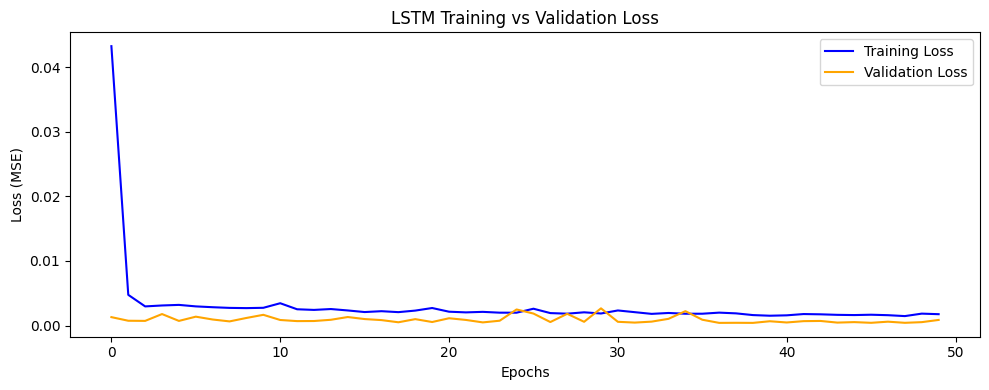

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
LSTM → RMSE: 62.17 | MAE: 54.88 | R²: 0.6567


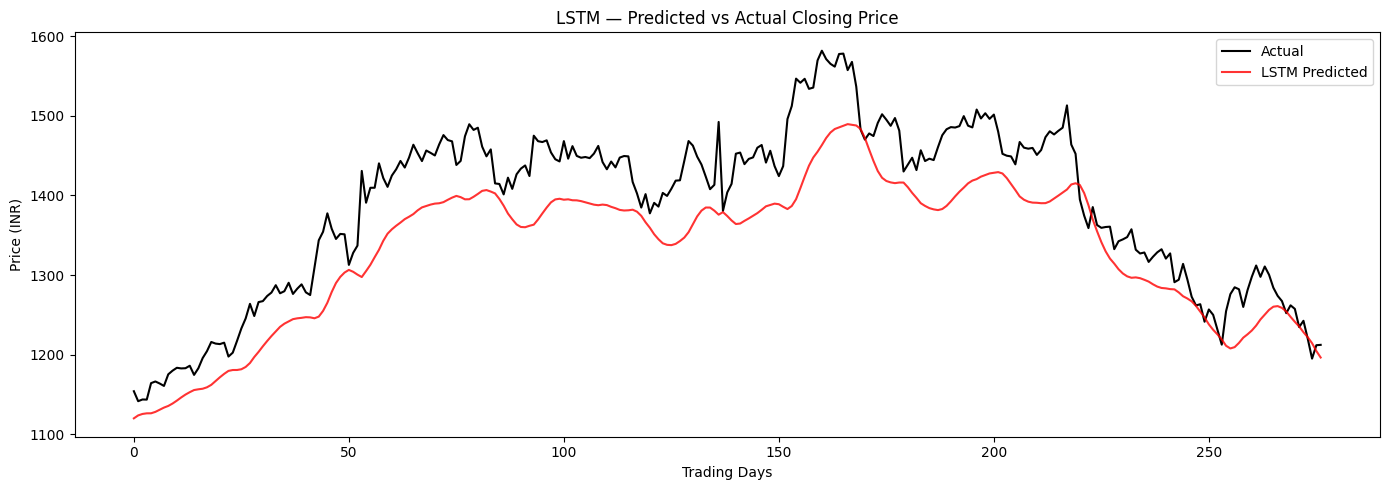

In [14]:
# Train LSTM
history = model.fit(
    X_train_l, y_train_l,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()

# Evaluate on test set
lstm_pred_scaled = model.predict(X_test_l)
lstm_pred = scaler_lstm.inverse_transform(lstm_pred_scaled)
y_test_actual_lstm = scaler_lstm.inverse_transform(y_test_l)

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual_lstm, lstm_pred))
lstm_mae = mean_absolute_error(y_test_actual_lstm, lstm_pred)
lstm_r2 = r2_score(y_test_actual_lstm, lstm_pred)

print(f"LSTM → RMSE: {lstm_rmse:.2f} | MAE: {lstm_mae:.2f} | R²: {lstm_r2:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual_lstm, label='Actual', color='black')
plt.plot(lstm_pred, label='LSTM Predicted', color='red', alpha=0.8)
plt.title('LSTM — Predicted vs Actual Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150)
plt.show()

Model                         RMSE      MAE       R²
Linear Regression            18.03    12.74   0.9756
Random Forest                20.46    14.70   0.9686
LSTM                         62.17    54.88   0.6567


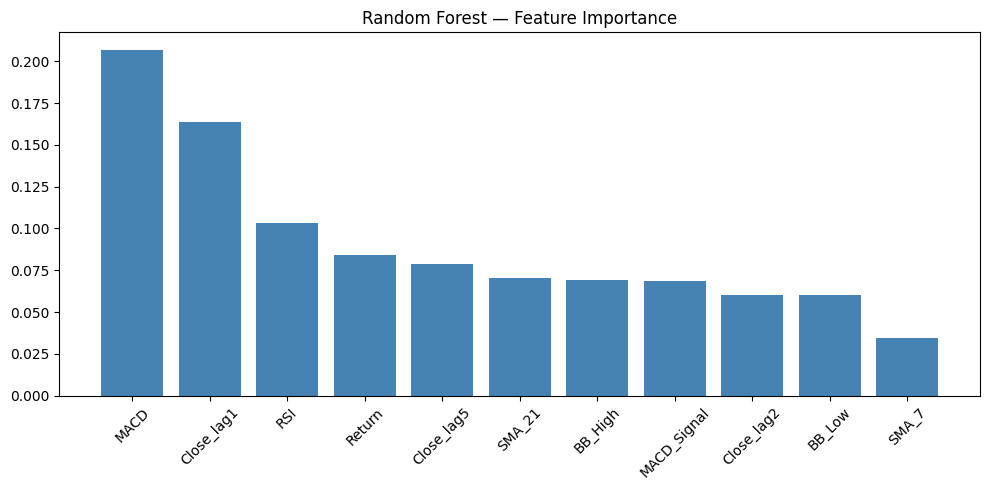

In [15]:
# Model comparison table
print("=" * 55)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("=" * 55)
print(f"{'Linear Regression':<25} {lr_rmse:>8.2f} {mean_absolute_error(actual_prices, lr_price_pred):>8.2f} {lr_r2:>8.4f}")
print(f"{'Random Forest':<25} {rf_rmse:>8.2f} {mean_absolute_error(actual_prices, rf_price_pred):>8.2f} {rf_r2:>8.4f}")
print(f"{'LSTM':<25} {lstm_rmse:>8.2f} {lstm_mae:>8.2f} {lstm_r2:>8.4f}")
print("=" * 55)

# Feature importance from Random Forest
feature_names = ['SMA_7', 'SMA_21', 'RSI', 'MACD',
                 'MACD_Signal', 'BB_High', 'BB_Low',
                 'Close_lag1', 'Close_lag2', 'Close_lag5', 'Return']

importances = rf2.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45)
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0320 - val_loss: 0.0032
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0049 - val_loss: 6.2144e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0032 - val_loss: 3.3081e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0030 - val_loss: 4.3181e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0030 - val_loss: 4.2230e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0025 - val_loss: 3.1561e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0024 - val_loss: 3.0657e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0032 - val_loss: 3.9701e-04
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - val_loss: 3.2453e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0023 - val_loss: 3.2300e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0024 - val_loss: 2.9465e-04
Epoch 12/50
32/32 ━━━

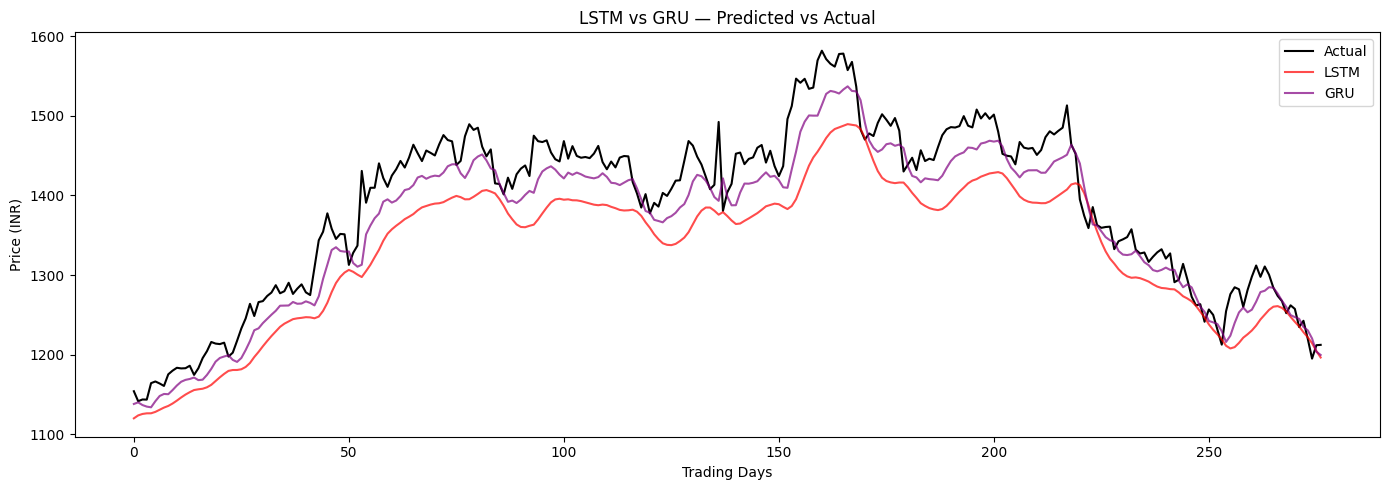

In [17]:
from tensorflow.keras.layers import GRU

# Build GRU model (same architecture as LSTM)
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    GRU(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train
gru_history = gru_model.fit(
    X_train_l, y_train_l,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
gru_pred_scaled = gru_model.predict(X_test_l)
gru_pred = scaler_lstm.inverse_transform(gru_pred_scaled)

gru_rmse = np.sqrt(mean_squared_error(y_test_actual_lstm, gru_pred))
gru_mae = mean_absolute_error(y_test_actual_lstm, gru_pred)
gru_r2 = r2_score(y_test_actual_lstm, gru_pred)

print(f"GRU → RMSE: {gru_rmse:.2f} | MAE: {gru_mae:.2f} | R²: {gru_r2:.4f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual_lstm, label='Actual', color='black')
plt.plot(lstm_pred, label='LSTM', color='red', alpha=0.7)
plt.plot(gru_pred, label='GRU', color='purple', alpha=0.7)
plt.title('LSTM vs GRU — Predicted vs Actual')
plt.xlabel('Trading Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_vs_gru.png', dpi=150)
plt.show()

[*********************100%***********************]  1 of 1 completed


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
TCS Validation → RMSE: 86.37 | MAE: 69.07 | R²: 0.9067


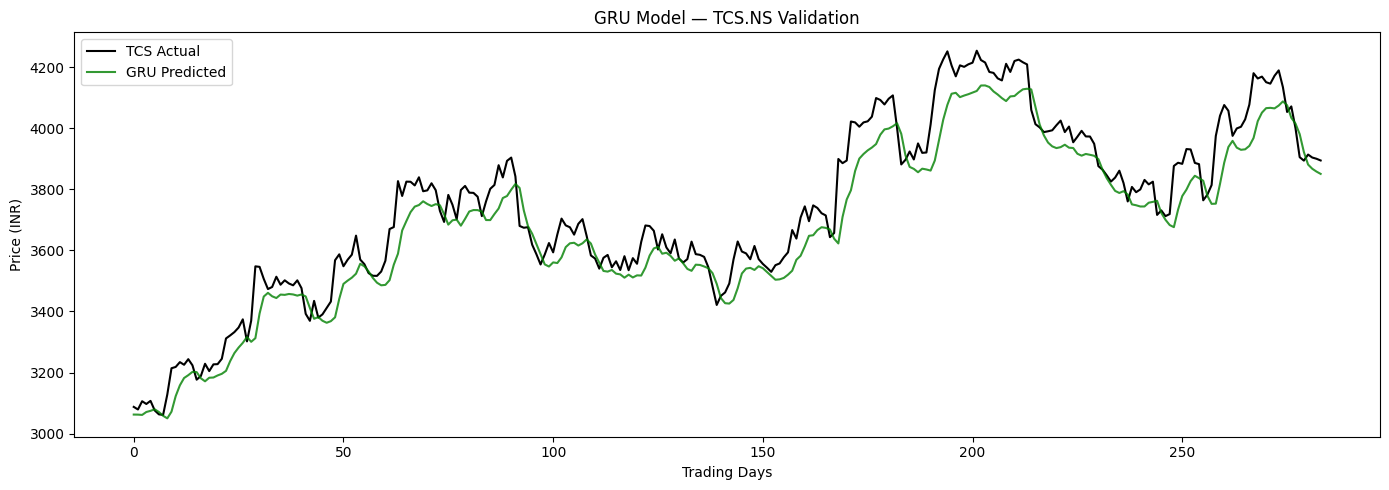

In [18]:
# Download TCS data for generalizability test
tcs = yf.download('TCS.NS', start='2019-01-01', end='2024-12-31')
tcs.columns = tcs.columns.get_level_values(0)
tcs.dropna(inplace=True)

# Scale TCS close price
scaler_tcs = MinMaxScaler()
tcs_scaled = scaler_tcs.fit_transform(tcs['Close'].values.reshape(-1, 1))

# Create sequences
X_tcs, y_tcs = create_sequences(tcs_scaled, tcs_scaled, lookback)

# Use last 20% as test
split_tcs = int(len(X_tcs) * 0.8)
X_test_tcs = X_tcs[split_tcs:]
y_test_tcs = y_tcs[split_tcs:]

# Predict using trained GRU model (best model)
tcs_pred_scaled = gru_model.predict(X_test_tcs)
tcs_pred = scaler_tcs.inverse_transform(tcs_pred_scaled)
tcs_actual = scaler_tcs.inverse_transform(y_test_tcs)

tcs_rmse = np.sqrt(mean_squared_error(tcs_actual, tcs_pred))
tcs_mae = mean_absolute_error(tcs_actual, tcs_pred)
tcs_r2 = r2_score(tcs_actual, tcs_pred)

print(f"TCS Validation → RMSE: {tcs_rmse:.2f} | MAE: {tcs_mae:.2f} | R²: {tcs_r2:.4f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(tcs_actual, label='TCS Actual', color='black')
plt.plot(tcs_pred, label='GRU Predicted', color='green', alpha=0.8)
plt.title('GRU Model — TCS.NS Validation')
plt.xlabel('Trading Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('tcs_validation.png', dpi=150)
plt.show()


In [19]:
# Final comprehensive comparison table
print("=" * 65)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Stock':>10}")
print("=" * 65)
print(f"{'Linear Regression':<25} {lr_rmse:>8.2f} {mean_absolute_error(actual_prices, lr_price_pred):>8.2f} {lr_r2:>8.4f} {'RELIANCE':>10}")
print(f"{'Random Forest':<25} {rf_rmse:>8.2f} {mean_absolute_error(actual_prices, rf_price_pred):>8.2f} {rf_r2:>8.4f} {'RELIANCE':>10}")
print(f"{'LSTM':<25} {lstm_rmse:>8.2f} {lstm_mae:>8.2f} {lstm_r2:>8.4f} {'RELIANCE':>10}")
print(f"{'GRU':<25} {gru_rmse:>8.2f} {gru_mae:>8.2f} {gru_r2:>8.4f} {'RELIANCE':>10}")
print(f"{'GRU (Generalization)':<25} {tcs_rmse:>8.2f} {tcs_mae:>8.2f} {tcs_r2:>8.4f} {'TCS':>10}")
print("=" * 65)

Model                         RMSE      MAE       R²      Stock
Linear Regression            18.03    12.74   0.9756   RELIANCE
Random Forest                20.46    14.70   0.9686   RELIANCE
LSTM                         62.17    54.88   0.6567   RELIANCE
GRU                          32.79    27.19   0.9045   RELIANCE
GRU (Generalization)         86.37    69.07   0.9067        TCS


In [20]:
from google.colab import files

# Save all plots
files.download('closing_price.png')
files.download('correlation_heatmap.png')
files.download('baseline_models.png')
files.download('lstm_loss.png')
files.download('lstm_predictions.png')
files.download('lstm_vs_gru.png')
files.download('tcs_validation.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>